#  ***Bio-Signal Analysis for Smoking***

**Problem** -  Build an intelligent
system from the data to determine the
presence or absence of smoking in a person
through bio-signals

 -- Import necessary libraries

--  Load dataset smoking.csv





In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import ExtraTreesClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,confusion_matrix
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [ ]:
df=pd.read_csv('/content/smoking.csv')

 Fetch First 5 observations

In [ ]:
df.head()

,ID,gender,age,height(cm),weight(kg),waist(cm),eyesight(left),eyesight(right),hearing(left),hearing(right),...,hemoglobin,Urine protein,serum creatinine,AST,ALT,Gtp,oral,dental caries,tartar,smoking
0,0,F,40,155,60,81.3,1.2,1.0,1.0,1.0,...,12.9,1.0,0.7,18.0,19.0,27.0,Y,0,Y,0
1,1,F,40,160,60,81.0,0.8,0.6,1.0,1.0,...,12.7,1.0,0.6,22.0,19.0,18.0,Y,0,Y,0
2,2,M,55,170,60,80.0,0.8,0.8,1.0,1.0,...,15.8,1.0,1.0,21.0,16.0,22.0,Y,0,N,1
3,3,M,40,165,70,88.0,1.5,1.5,1.0,1.0,...,14.7,1.0,1.0,19.0,26.0,18.0,Y,0,Y,0
4,4,F,40,155,60,86.0,1.0,1.0,1.0,1.0,...,12.5,1.0,0.6,16.0,14.0,22.0,Y,0,N,0


1. ID -  index

2. gender  - gender of a person (M or F)

3. age  - age of a person (5-years gap)

4. height(cm) -  height of a person

5. weight(kg)  - weight of a person

6. waist(cm)  - waist circumference length

7. eyesight(left) -  left eyesight

8. eyesight(right) -  right eyesight

9. hearing(left)  - hearing pulse in left ear

10. hearing(right)  - hearing pulse in right ear

11. systolic  - Blood pressure

12. relaxation  - Blood pressure

13. fasting blood sugar -  Blood test

14. Cholesterol -  total

15. triglyceride  - Lipid found in blood

16. HDL  - cholesterol type

17. LDL  - cholesterol type

18. hemoglobin  - Transporting oxygen in blood

19. Urine protein -  Excess of bloodborne proteins in urine

20. serum creatinine  - Amount of creatinine in blood

21. AST  - glutamic oxaloacetic transaminase type

22. ALT  - glutamic oxaloacetic transaminase type

23. Gtp -  γ-GTP

24. oral -  Oral Examination status

25. dental caries  - Tooth decay

26. tartar  - tartar status

27. smoking  - Smoker (0 or 1)





In [ ]:
print(df.shape)


(55692, 27)


This dataset is a collection of basic health biological signal data which
contains around 55K record with 27 attributes.

In [ ]:
df.drop(columns=['ID','oral'],axis=1,inplace=True)

 removing the irrelevant columns.

In [ ]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55692 entries, 0 to 55691
Data columns (total 25 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   gender               55692 non-null  object 
 1   age                  55692 non-null  int64  
 2   height(cm)           55692 non-null  int64  
 3   weight(kg)           55692 non-null  int64  
 4   waist(cm)            55692 non-null  float64
 5   eyesight(left)       55692 non-null  float64
 6   eyesight(right)      55692 non-null  float64
 7   hearing(left)        55692 non-null  float64
 8   hearing(right)       55692 non-null  float64
 9   systolic             55692 non-null  float64
 10  relaxation           55692 non-null  float64
 11  fasting blood sugar  55692 non-null  float64
 12  Cholesterol          55692 non-null  float64
 13  triglyceride         55692 non-null  float64
 14  HDL                  55692 non-null  float64
 15  LDL                  55692 non-null 

,age,height(cm),weight(kg),waist(cm),eyesight(left),eyesight(right),hearing(left),hearing(right),systolic,relaxation,...,HDL,LDL,hemoglobin,Urine protein,serum creatinine,AST,ALT,Gtp,dental caries,smoking
count,55692.000000,55692.000000,55692.000000,55692.000000,55692.000000,55692.000000,55692.000000,55692.000000,55692.000000,55692.000000,...,55692.000000,55692.000000,55692.000000,55692.000000,55692.000000,55692.000000,55692.000000,55692.000000,55692.000000,55692.000000
mean,44.182917,164.649321,65.864936,82.046418,1.012623,1.007443,1.025587,1.026144,121.494218,76.004830,...,57.290347,114.964501,14.622592,1.087212,0.885738,26.182935,27.036037,39.952201,0.213334,0.367288
std,12.071418,9.194597,12.820306,9.274223,0.486873,0.485964,0.157902,0.159564,13.675989,9.679278,...,14.738963,40.926476,1.564498,0.404882,0.221524,19.355460,30.947853,50.290539,0.409665,0.482070
min,20.000000,130.000000,30.000000,51.000000,0.100000,0.100000,1.000000,1.000000,71.000000,40.000000,...,4.000000,1.000000,4.900000,1.000000,0.100000,6.000000,1.000000,1.000000,0.000000,0.000000
25%,40.000000,160.000000,55.000000,76.000000,0.800000,0.800000,1.000000,1.000000,112.000000,70.000000,...,47.000000,92.000000,13.600000,1.000000,0.800000,19.000000,15.000000,17.000000,0.000000,0.000000
50%,40.000000,165.000000,65.000000,82.000000,1.000000,1.000000,1.000000,1.000000,120.000000,76.000000,...,55.000000,113.000000,14.800000,1.000000,0.900000,23.000000,21.000000,25.000000,0.000000,0.000000
75%,55.000000,170.000000,75.000000,88.000000,1.200000,1.200000,1.000000,1.000000,130.000000,82.000000,...,66.000000,136.000000,15.800000,1.000000,1.000000,28.000000,31.000000,43.000000,0.000000,1.000000
max,85.000000,190.000000,135.000000,129.000000,9.900000,9.900000,2.000000,2.000000,240.000000,146.000000,...,618.000000,1860.000000,21.100000,6.000000,11.600000,1311.000000,2914.000000,999.000000,1.000000,1.000000


Checking the shape of a dataframe and datatypes of all columns
along with calculating the statistical data.

In [ ]:
df.isnull().sum().sum()

np.int64(0)

Checking out the missing values in a dataframe

# **Data Visualization**

We can clearly see from the below graph that most smokers are men

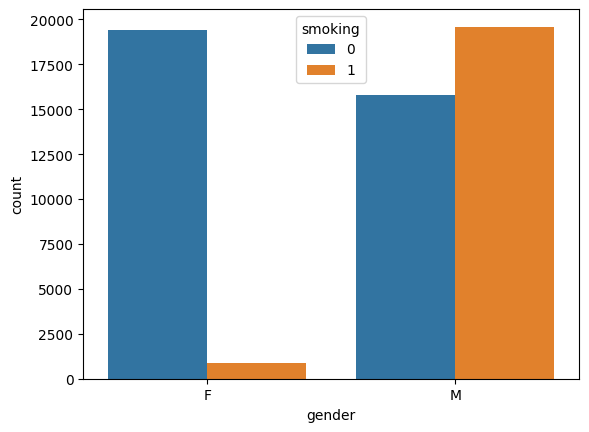

In [ ]:
sns.countplot(x='gender',hue='smoking',data=df)
plt.show()

There are 36.73 percent of the people who are smoking ciggarette.

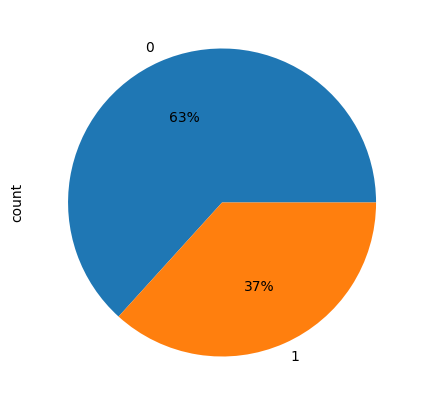

In [ ]:
plt.figure(figsize=(10,5))
df['smoking'].value_counts().plot.pie(autopct='%2.f%%')
plt.show()

Most number of smokers are having the age 40

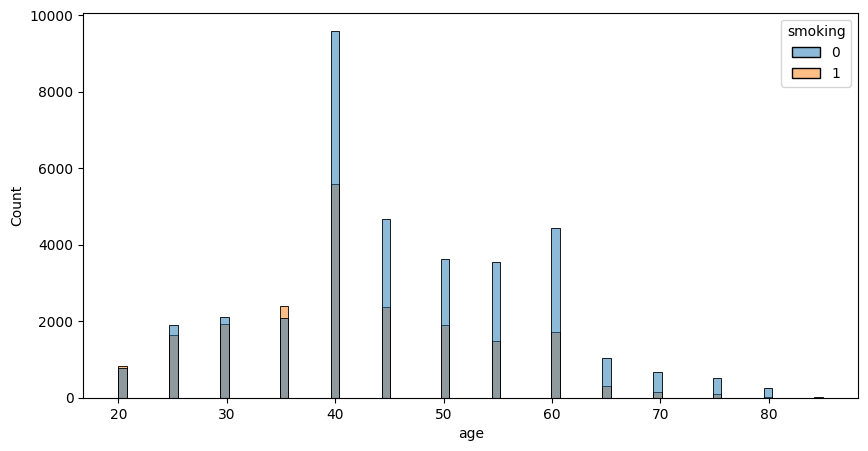

In [ ]:
plt.figure(figsize=(10,5))
sns.histplot(x='age',hue='smoking',data=df)
plt.show()

Representation of columns using boxplot to detect outliers. Here outliers represent natural
variations in the population, and they should be left as is in the dataset. These are called true
outliers. Therefore for this dataset we will not remove outliers.

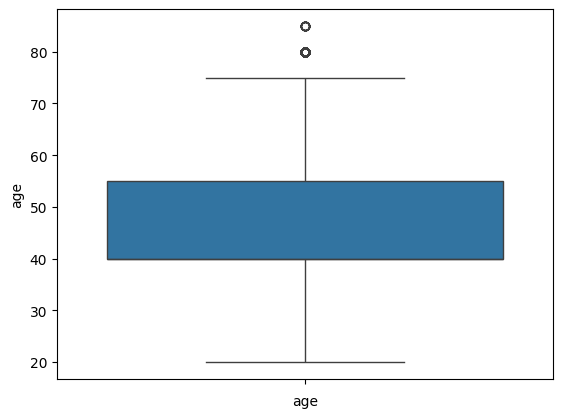

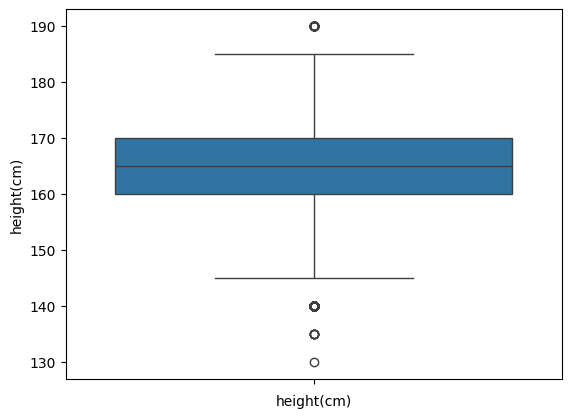

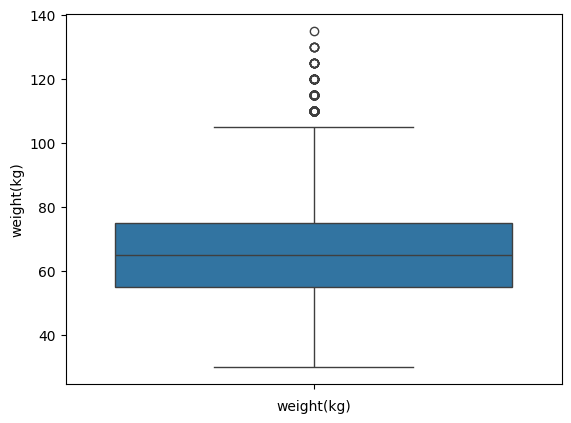

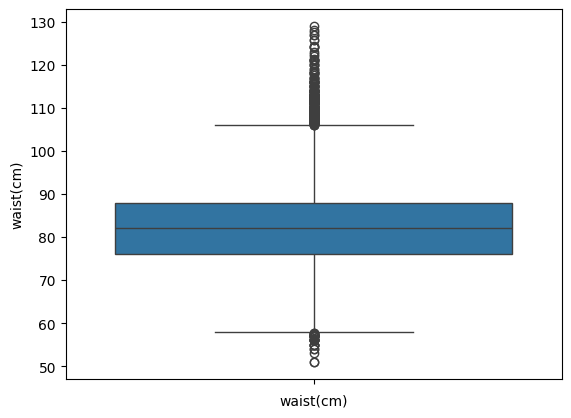

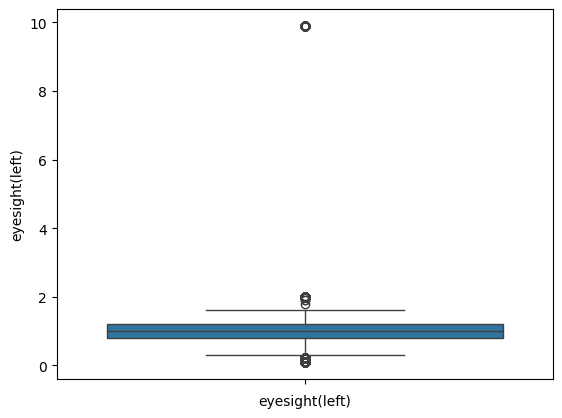

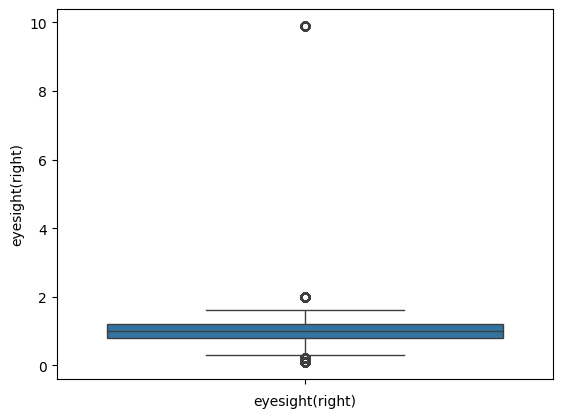

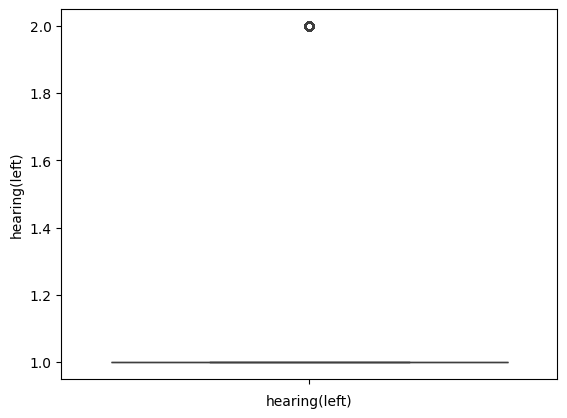

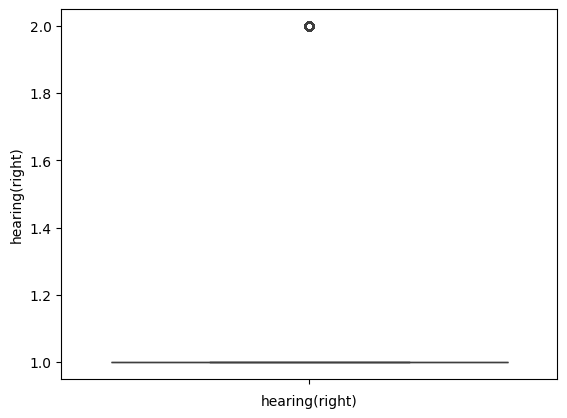

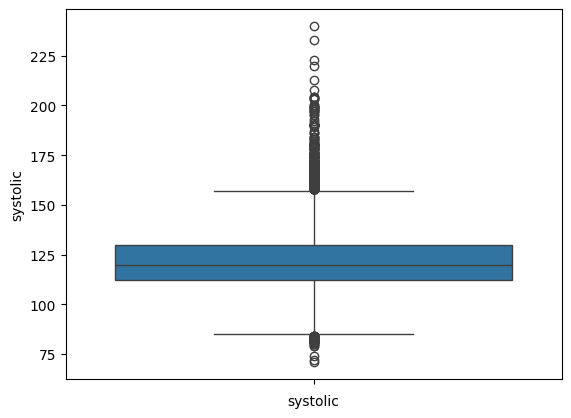

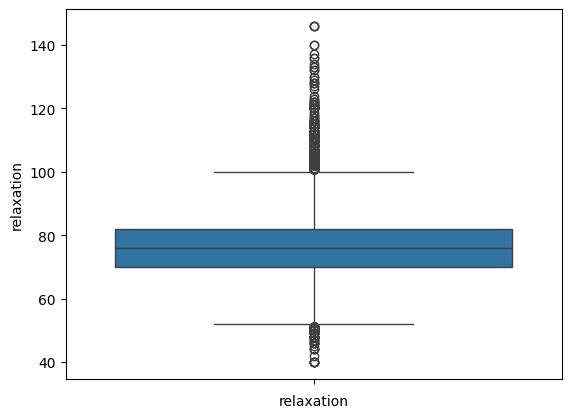

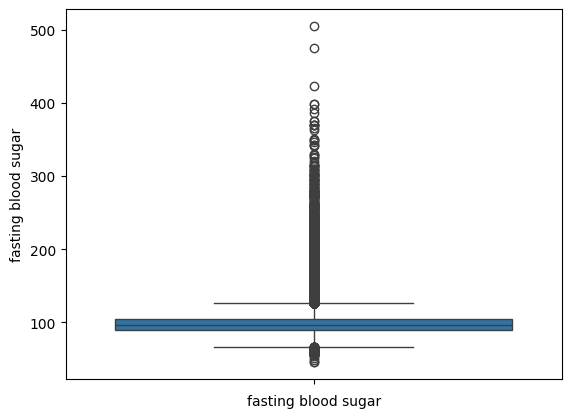

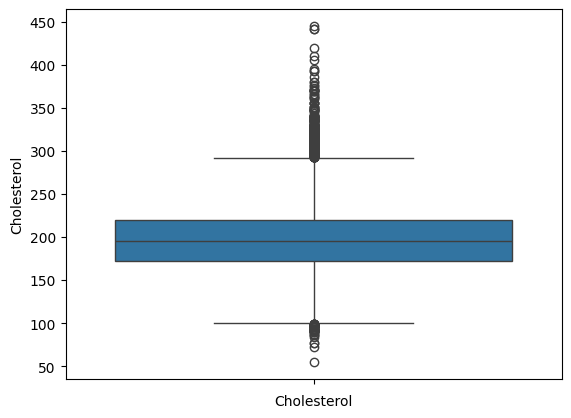

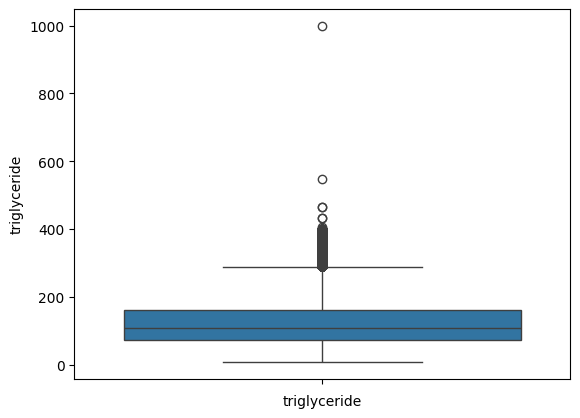

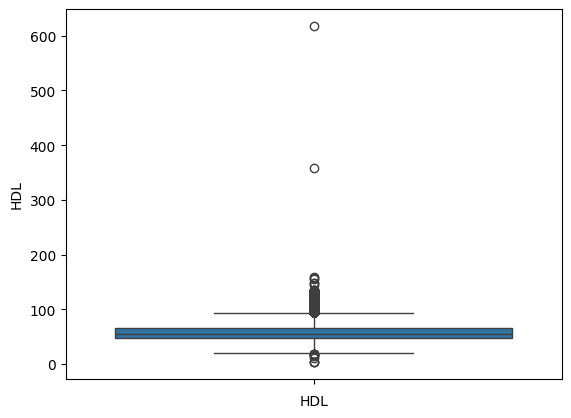

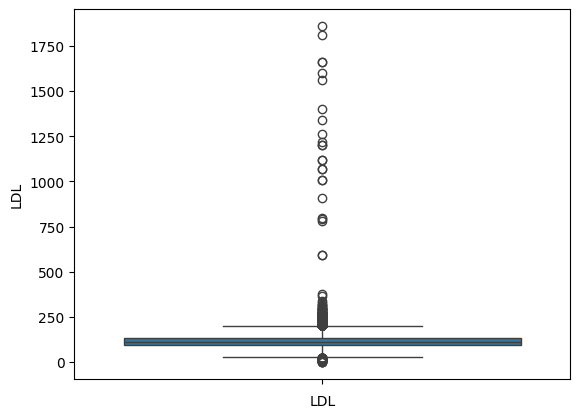

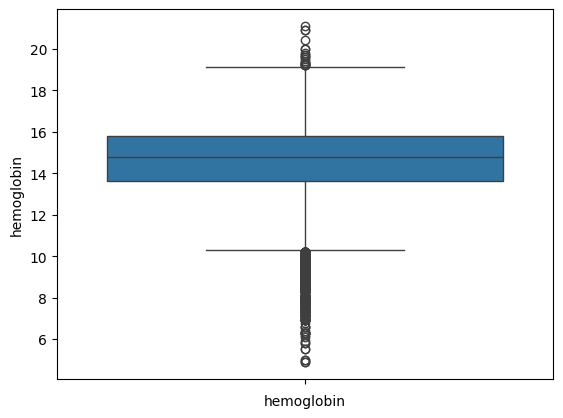

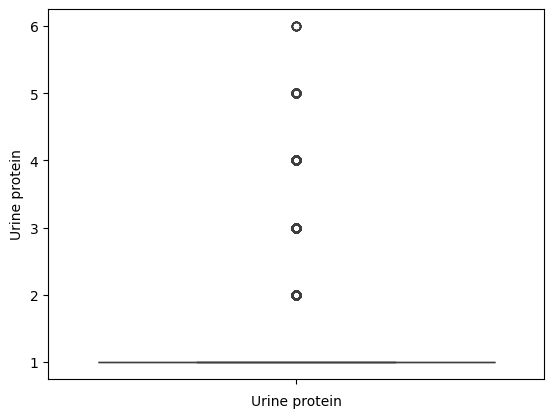

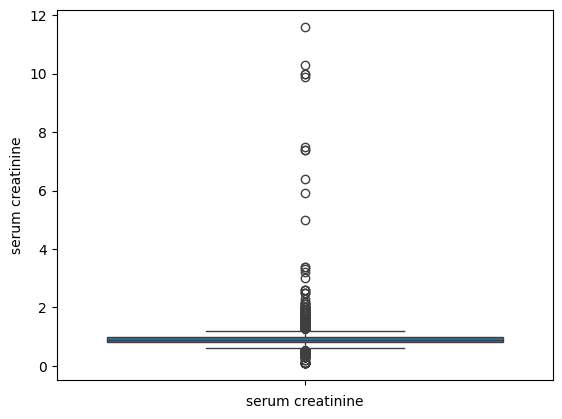

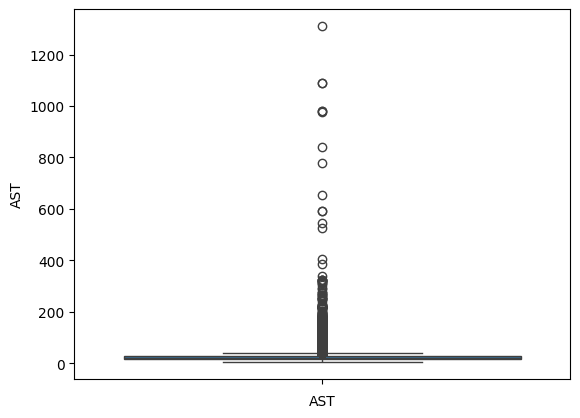

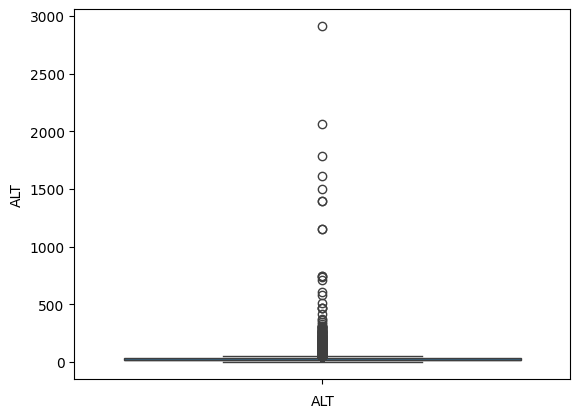

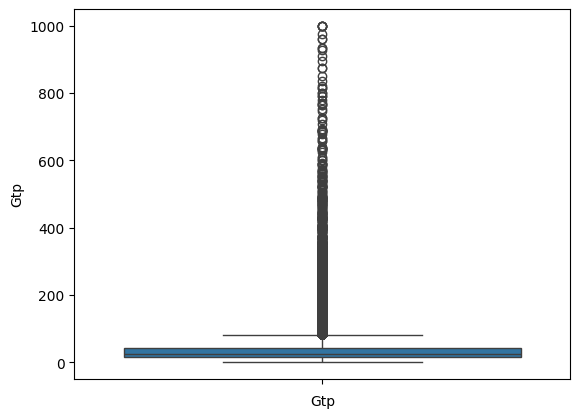

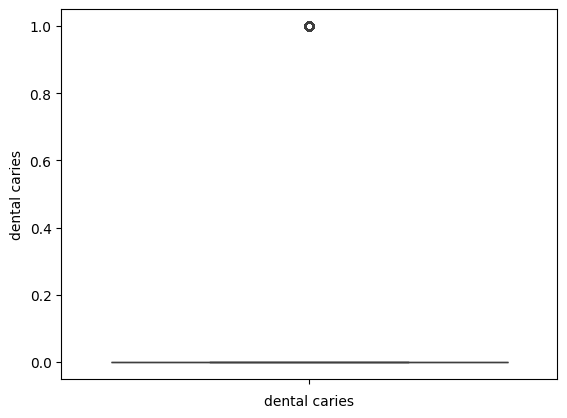

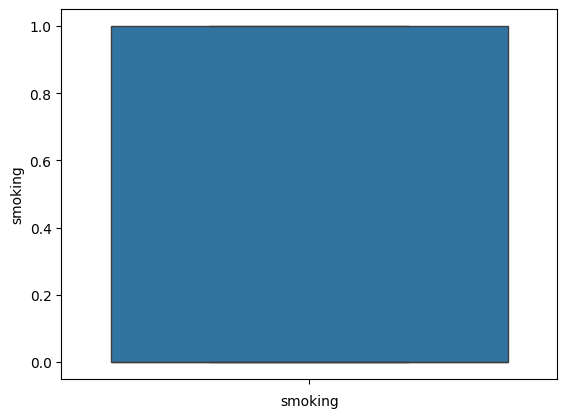

In [ ]:
for i in df.columns:
  if df[i].dtype == 'int64' or df[i].dtype == 'float64':
   sns.boxplot(df[i])
   plt.xlabel(i)
   plt.show()

# **Feature selection using feature importance**
Feature importance is a technique
that calculate a score for all the
input features for a given model. So
out of 24 features we will select the
top 15 features based on the score

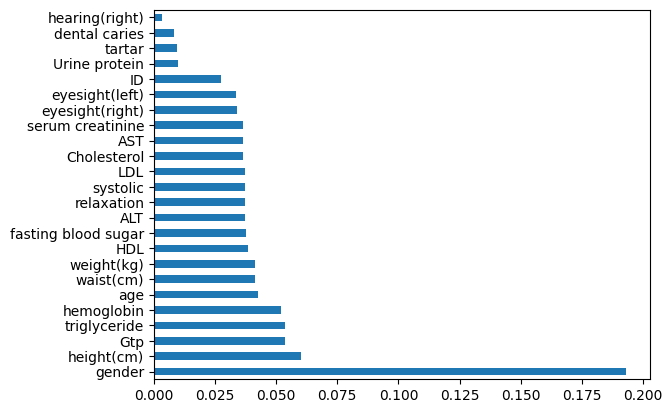

In [ ]:
X = df.drop('smoking',axis=1)
y = df['smoking']
from sklearn.ensemble import ExtraTreesClassifier
model = ExtraTreesClassifier()
model.fit(X,y)
df1=pd.Series(model.feature_importances_,index=X.columns)
df1.nlargest(24).plot(kind='barh')
plt.show()

Performing Label  Encoding for
categorical features of a dataframe

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['oral'] = le.fit_transform(df['oral'])
df['gender'] = le.fit_transform(df['gender'])
df['tartar'] = le.fit_transform(df['tartar'])
df['dental caries'] = le.fit_transform(df['dental caries'])

In [ ]:
df.dtypes

,0
ID,int64
gender,int64
age,int64
height(cm),int64
weight(kg),int64
waist(cm),float64
eyesight(left),float64
eyesight(right),float64
hearing(left),float64
hearing(right),float64


In [ ]:
df.dtypes

,0
ID,int64
gender,object
age,int64
height(cm),int64
weight(kg),int64
waist(cm),float64
eyesight(left),float64
eyesight(right),float64
hearing(left),float64
hearing(right),float64


# Logistic Regression -
1. split data train 80 ,test 20
2. perform logistic reg

In [ ]:
X = df[['age','weight(kg)','waist(cm)','Gtp','ALT','AST','hemoglobin','oral','tartar','dental caries']]
y = df['smoking']

In [ ]:
#training data and spliting..
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)
# standard scaling - making all values in a range
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)
# logistic regression - building sigmoid function
log_model=LogisticRegression()
log_model.fit(X_train,y_train)
#test data
y_pred=log_model.predict(X_test)

In [ ]:
#Calculating accuracy and generating the classification report of Logistic Regression
accuracy_score(y_test,y_pred)

0.7021276595744681

The accuracy of the logistic regression model is
70 percentage

# **Decision Tree**

In [ ]:
dec_model1=DecisionTreeClassifier()
dec_model1.fit(X_train,y_train)

y_pred=dec_model1.predict(X_test)

In [ ]:
accuracy_score(y_test,y_pred)

0.770895053415926

The accuracy of the decision tree model is
77 percentage

# **Random Forest**

In [ ]:
ran_model2=RandomForestClassifier()
ran_model2.fit(X_train,y_train)

y_pred=ran_model2.predict(X_test)

In [ ]:

accuracy_score(y_test,y_pred)

0.8094083849537661

In [ ]:
confusion_matrix(y_test,y_pred)

array([[6038,  989],
       [1134, 2978]])

The accuracy of the random forest model is
80 percentage

# **“Random Forest was selected due to its stability and ability to reduce overfitting while maintaining high accuracy.”**

TN = 6038	correctly predicted non-smokers

TP = 2978	correctly predicted smokers

FP = 989	predicted smoker but actually non-smoker

FN = 1134	missed smokers (VERY important error)

In [ ]:
from xgboost import XGBClassifier

model = XGBClassifier(
    scale_pos_weight=1.5,
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42
)

In [ ]:
model.fit(X_train,y_train)
y_pred = model.predict(X_test)

In [ ]:
accuracy_score(y_test,y_pred)
confusion_matrix(y_test,y_pred)

array([[5099, 1928],
       [ 949, 3163]])

In [ ]:
y_proba = model.predict_proba(X_test)[:, 1]
y_pred = (y_proba >= 0.4).astype(int)

In [ ]:
y_proba

array([0.00576697, 0.06343217, 0.5698626 , ..., 0.04121879, 0.34345168,
       0.7601989 ], dtype=float32)

In [ ]:
y_pred

array([0, 0, 1, ..., 0, 0, 1])